In [ ]:
# ============================================
# CELL 1 — START & IMPORTS
# ============================================

print("Starting Email Spam Detection AI Agent (Cell 1)")
print("Purpose: Import all required libraries.\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_auc_score)
from sklearn.linear_model import LogisticRegression
import nltk
import string
import re
import pickle

nltk.download("stopwords")
from nltk.corpus import stopwords

print("Cell 1 executed successfully: Libraries imported.\n")

Starting Email Spam Detection AI Agent (Cell 1)
Purpose: Import all required libraries.

Cell 1 executed successfully: Libraries imported.



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# ============================================
# CELL 2 — LOAD DATASET
# ============================================

print("Loading dataset (Cell 2)...")

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep="\t", names=["label", "message"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

print("Spam/Ham distribution:\n", df["label"].value_counts())
print("\nCell 2 executed successfully.\n")


Loading dataset (Cell 2)...
Dataset loaded successfully!
Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Spam/Ham distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

Cell 2 executed successfully.



In [ ]:
# ============================================
# CELL 3 — TEXT PREPROCESSING
# ============================================

print("Preprocessing text (Cell 3)...")

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

df["cleaned_text"] = df["message"].apply(preprocess_text)

print(df[["message", "cleaned_text"]].head())
print("\nCell 3 executed successfully.\n")


Preprocessing text (Cell 3)...
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                        cleaned_text  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  

Cell 3 executed successfully.



In [ ]:
# ============================================
# CELL 4 — TF-IDF VECTORIZATION
# ============================================

print("Converting text to TF-IDF features (Cell 4)...")

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["cleaned_text"]).toarray()
y = df["label"].map({"ham": 0, "spam": 1})

print("Vectorization Complete!")
print("Feature size:", X.shape)

print("\nCell 4 executed successfully.\n")


Converting text to TF-IDF features (Cell 4)...
Vectorization Complete!
Feature size: (5572, 5000)

Cell 4 executed successfully.



In [ ]:
# ============================================
# CELL 5 — SPLITTING DATASET
# ============================================

print("Splitting dataset into train and test sets (Cell 5)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nCell 5 executed successfully.\n")


Splitting dataset into train and test sets (Cell 5)...
Training samples: 4457
Testing samples: 1115

Cell 5 executed successfully.



In [ ]:
# ============================================
# CELL 6 — TRAIN LOGISTIC REGRESSION MODEL
# ============================================

print("Training Logistic Regression Model (Cell 6)...")

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print("Model training completed!")
print("\nCell 6 executed successfully.\n")


Training Logistic Regression Model (Cell 6)...
Model training completed!

Cell 6 executed successfully.



In [ ]:
# ============================================
# CELL 7 — MODEL EVALUATION
# ============================================

print("Evaluating model (Cell 7)...")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nCell 7 executed successfully.\n")


Evaluating model (Cell 7)...
Accuracy: 0.9614349775784753
Precision: 0.9732142857142857
Recall: 0.7315436241610739
F1 Score: 0.8352490421455939
ROC-AUC: 0.9883627218030486

Confusion Matrix:
 [[963   3]
 [ 40 109]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.97      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115


Cell 7 executed successfully.



In [ ]:
# ============================================
# CELL 8 — SPAM DETECTION AGENT FUNCTION
# ============================================

print("Creating agent function (Cell 8)...")

def classify_email(message):
    cleaned = preprocess_text(message)
    vector = vectorizer.transform([cleaned]).toarray()
    prediction = model.predict(vector)[0]
    prob = model.predict_proba(vector)[0][1]
    label = "SPAM" if prediction == 1 else "HAM (Not Spam)"
    return label, prob

# Test Agent
sample = "Congratulations! You have won a free gift. Click here!"
label, prob = classify_email(sample)

print("Sample:", sample)
print("Prediction:", label, "| Confidence:", prob)

print("\nCell 8 executed successfully.\n")


Creating agent function (Cell 8)...
Sample: Congratulations! You have won a free gift. Click here!
Prediction: HAM (Not Spam) | Confidence: 0.4232215966927223

Cell 8 executed successfully.



In [ ]:
# ============================================
# CELL 9 — SAVE MODEL
# ============================================

print("Saving model and vectorizer (Cell 9)...")

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

print("Model saved as 'spam_model.pkl'")
print("Vectorizer saved as 'tfidf_vectorizer.pkl'")
print("\nAll cells executed successfully — AI Agent is READY!\n")


Saving model and vectorizer (Cell 9)...
Model saved as 'spam_model.pkl'
Vectorizer saved as 'tfidf_vectorizer.pkl'

All cells executed successfully — AI Agent is READY!



In [ ]:
# Test with your input message
your_message = input("Enter the email text: ")

label, probability = classify_email(your_message)

print("\nRESULT")
print("Your Message:", your_message)
print("Prediction:", label)
print(f"Confidence Score: {probability:.4f}")


Enter the email text: You won a lottery

RESULT
Your Message: You won a lottery
Prediction: HAM (Not Spam)
Confidence Score: 0.0749


Plotting performance metrics...


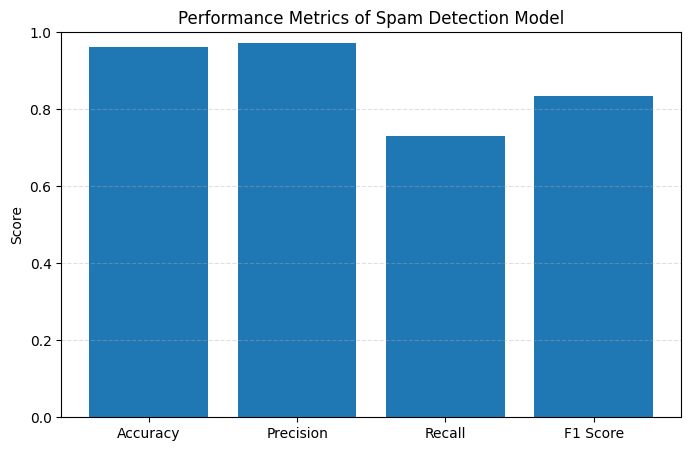

Graph generated successfully!



In [ ]:

# ============================================
# CELL A — BAR GRAPH OF PERFORMANCE METRICS
# ============================================

print("Plotting performance metrics...")

# Metrics from your model (already computed earlier)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.title("Performance Metrics of Spam Detection Model")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

print("Graph generated successfully!\n")


Plotting confusion matrix heatmap...


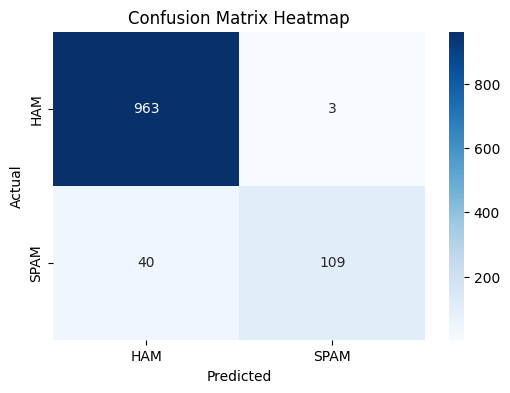

Confusion matrix heatmap generated!



In [ ]:
# ============================================
# CELL B — CONFUSION MATRIX HEATMAP
# ============================================

import seaborn as sns

print("Plotting confusion matrix heatmap...")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["HAM", "SPAM"],
            yticklabels=["HAM", "SPAM"])
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion matrix heatmap generated!\n")


Plotting ROC curve...


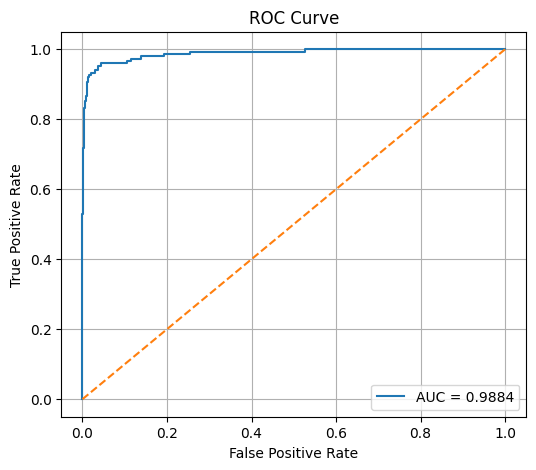

ROC curve generated!



In [ ]:
# ============================================
# CELL C — ROC CURVE
# ============================================

from sklearn.metrics import roc_curve

print("Plotting ROC curve...")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("ROC curve generated!\n")
